In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

# Downloads/loads record 100 from the public MIT-BIH ECG dataset
record = wfdb.rdrecord("100", pn_dir="mitdb")

signals = record.p_signal
fs = record.fs

print("Signal shape:", signals.shape)
print("Sampling rate:", fs, "Hz")
print("ECG leads:", record.sig_name)
print("Units:", record.units)

Signal shape: (650000, 2)
Sampling rate: 360 Hz
ECG leads: ['MLII', 'V5']
Units: ['mV', 'mV']


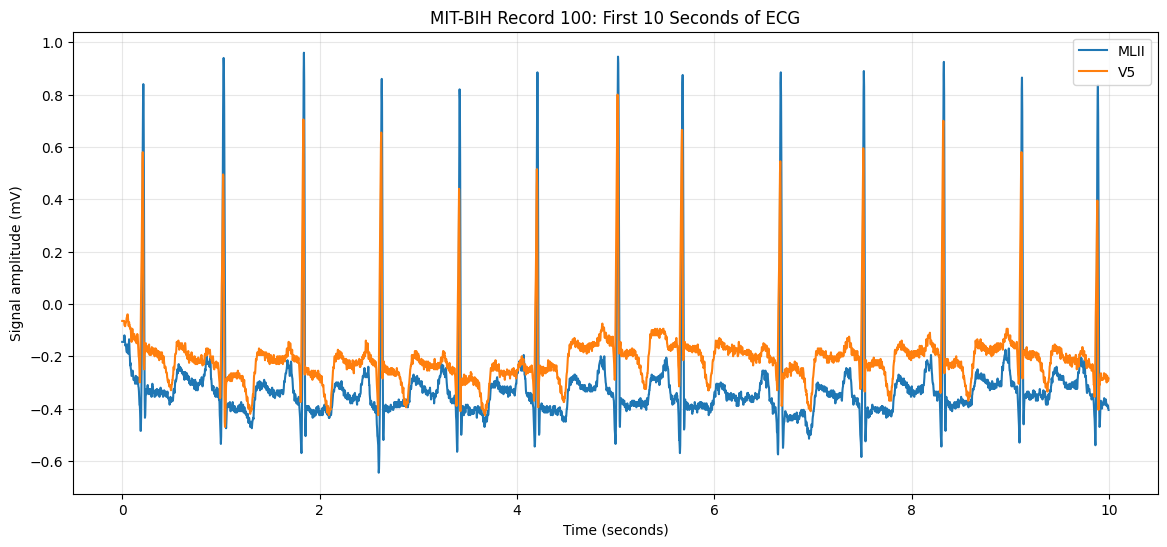

In [ ]:
seconds = 10
n_samples = int(seconds * fs)

time = np.arange(n_samples) / fs

plt.figure(figsize=(14, 6))

for i, lead_name in enumerate(record.sig_name):
    plt.plot(time, signals[:n_samples, i], label=lead_name)

plt.title("MIT-BIH Record 100: First 10 Seconds of ECG")
plt.xlabel("Time (seconds)")
plt.ylabel("Signal amplitude (mV)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
annotations = wfdb.rdann("100", "atr", pn_dir="mitdb")

print("Number of annotated beats:", len(annotations.sample))
print("First 15 annotation symbols:", annotations.symbol[:15])

Number of annotated beats: 2274
First 15 annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N']


In [ ]:
signal_table = pd.DataFrame({
    "time_seconds": time,
    "MLII_mV": signals[:n_samples, 0],
    "V5_mV": signals[:n_samples, 1]
})

signal_table.head(15)

,time_seconds,MLII_mV,V5_mV
0,0.000000,-0.145,-0.065
1,0.002778,-0.145,-0.065
2,0.005556,-0.145,-0.065
3,0.008333,-0.145,-0.065
4,0.011111,-0.145,-0.065
5,0.013889,-0.145,-0.065
6,0.016667,-0.145,-0.065
7,0.019444,-0.145,-0.065
8,0.022222,-0.120,-0.080
9,0.025000,-0.135,-0.080


In [ ]:
import pandas as pd

annotation_df = pd.DataFrame({
    "sample_number": annotations.sample,
    "time_seconds": annotations.sample / fs,
    "annotation_label": annotations.symbol
})

annotation_df.head(15)

,sample_number,time_seconds,annotation_label
0,18,0.050000,+
1,77,0.213889,N
2,370,1.027778,N
3,662,1.838889,N
4,946,2.627778,N
5,1231,3.419444,N
6,1515,4.208333,N
7,1809,5.025000,N
8,2044,5.677778,A
9,2402,6.672222,N


In [ ]:
event_table = annotation_df.copy()

event_table["MLII_mV"] = signals[annotations.sample, 0]
event_table["V5_mV"] = signals[annotations.sample, 1]

event_table.head(15)

,sample_number,time_seconds,annotation_label,MLII_mV,V5_mV
0,18,0.050000,+,-0.170,-0.050
1,77,0.213889,N,0.840,0.210
2,370,1.027778,N,0.940,0.360
3,662,1.838889,N,0.885,0.610
4,946,2.627778,N,0.810,0.545
5,1231,3.419444,N,0.820,0.155
6,1515,4.208333,N,0.885,0.175
7,1809,5.025000,N,0.945,0.595
8,2044,5.677778,A,0.845,0.500
9,2402,6.672222,N,0.845,0.450
